## Experiment 01: Feature Engineering for Machine Learning
## Title: Handling Missing Values, Encoding Categorical Variables, and Scaling Numerical Attributes

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 01 : Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


### Step 2: Load the Dataset (Auto MPG - fuel efficiency dataset)

In [2]:
df = sns.load_dataset("mpg")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Step 3: Explore Dataset Structure 

In [3]:
print("Column Data Types: ")
print(df.dtypes)

print("\nBasic Statistics: ")
df.describe()

Column Data Types: 
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Basic Statistics: 


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


### Step 4: Check for Msissing Values


In [4]:
missing_values = df.isnull().sum()
print("\nMissing Values: ")
print(missing_values[missing_values > 0])

print("\nTotal Missing Values: ", df.isnull().sum().sum())


Missing Values: 
horsepower    6
dtype: int64

Total Missing Values:  6


### Step 5: Handle Missing Values

In [5]:
imputer = SimpleImputer(strategy='median')
df["horsepower"] = imputer.fit_transform(df[["horsepower"]])

print("\nMissing Values After Imputation: ")
print(df.isnull().sum().sum())

df[["horsepower"]].describe()


Missing Values After Imputation: 
0


,horsepower
count,398.000000
mean,104.304020
std,38.222625
min,46.000000
25%,76.000000
50%,93.500000
75%,125.000000
max,230.000000


### Step 6: Drop Irrelevant Columns

In [6]:
df = df.drop(columns=["name"])

print("Remaining Columns: ", df.columns.tolist())

Remaining Columns:  ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']


### Step 7: Identify Categorical and Numerical Columns


In [7]:
categorical_cols = ["origin"]
numerical_cols   = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

print("\nCategorical Columns: ", categorical_cols)
print("Numerical Columns: ", numerical_cols)

# If categorical columns are more that 1, we can use a loop to print unique values for each categorical column
# print("\nUnique Values in Categorical Columns: ")
# for col in categorical_cols:
#     print(f"{col}: {df[col].unique()}")

print("\nUnique values in 'origin':", df["origin"].unique())


Categorical Columns:  ['origin']
Numerical Columns:  ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

Unique values in 'origin': <StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str


### Step 8: Encode Categorical Variables

In [8]:
df_encoded = pd.get_dummies(df, columns=["origin"], prefix="origin")

print("\nColumns after One-Hot Encoding: ", df_encoded.columns.tolist())

df_encoded.head()


Columns after One-Hot Encoding:  ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_europe', 'origin_japan', 'origin_usa']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,False,True


### Step 9: Scale Numerical Attributes (Standardization and Normalization)

In [9]:
scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols]) 

# For verification, we can print the mean and standard deviation of the scaled numerical columns to ensure they are approximately 0 and 1, respectively.
# print("Numerical columns after scaling (mean = 0, std = 1):")
# for col in numerical_cols:
#     print(f"{col}: Mean = {df_scaled[col].mean():.2f}, Std = {df_scaled[col].std():.2f}")

df_scaled[numerical_cols].describe().round(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000,398.000,398.000,398.000,398.000,398.000,398.000
mean,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.859,-1.445,-1.204,-1.527,-1.605,-2.748,-1.627
25%,-0.770,-0.856,-0.856,-0.741,-0.883,-0.633,-0.815
50%,-0.066,-0.856,-0.431,-0.283,-0.197,-0.025,-0.003
75%,0.703,1.498,0.658,0.542,0.754,0.583,0.810
max,2.957,1.498,2.512,3.293,2.565,3.352,1.622


### Step 10: Compare Before and After Scaling

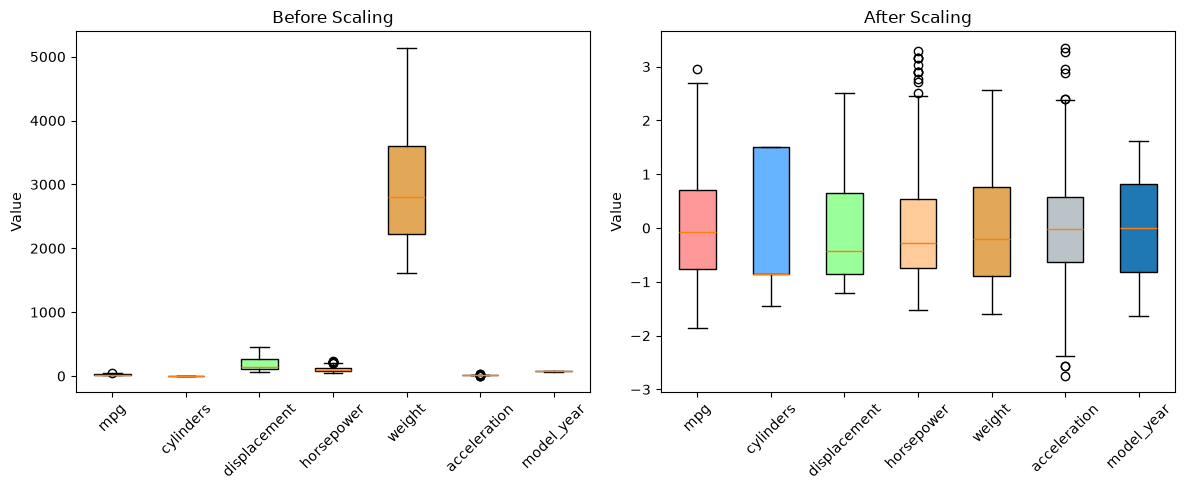

In [10]:
colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#E3A857', '#BAC4C8']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Plot before scaling
bp1 = axes[0].boxplot(df_encoded[numerical_cols].values, patch_artist=True)
axes[0].set_title("Before Scaling")
axes[0].set_ylabel("Value")
axes[0].set_xticklabels(numerical_cols, rotation=45)

# 2. Plot after scaling
bp2 = axes[1].boxplot(df_scaled[numerical_cols].values, patch_artist=True)
axes[1].set_title("After Scaling")
axes[1].set_ylabel("Value")
axes[1].set_xticklabels(numerical_cols, rotation=45)

# Apply individual colors to the boxes in both plots
for bp in [bp1, bp2]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

plt.tight_layout()
plt.show()

### Step 11: Final Model-Ready Dataset

In [11]:
print("Final Dataset Shape: ", df_scaled.shape)
print("\nColumns List: ")
print(df_scaled.columns.tolist())

print("\nMissing Values in Final Dataset: ")
print(df_scaled.isnull().sum().sum())

df_scaled.head()

Final Dataset Shape:  (398, 10)

Columns List: 
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_europe', 'origin_japan', 'origin_usa']

Missing Values in Final Dataset: 
0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,-0.706439,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,False,False,True
1,-1.090751,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,False,False,True
2,-0.706439,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,False,False,True
3,-0.962647,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,False,False,True
4,-0.834543,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,False,False,True


### Final Output 

In [12]:
print("Experiment Completed Successfully")
print("\nOriginal dataset shape :", df.shape)
print("Final dataset shape    :", df_scaled.shape)
print("Missing values handled : Yes (horsepower - median imputation)")
print("Categorical encoded    : Yes (origin - one-hot encoding)")
print("Numerical scaled       : Yes (StandardScaler on 7 columns)")

Experiment Completed Successfully

Original dataset shape : (398, 8)
Final dataset shape    : (398, 10)
Missing values handled : Yes (horsepower - median imputation)
Categorical encoded    : Yes (origin - one-hot encoding)
Numerical scaled       : Yes (StandardScaler on 7 columns)
